# NorthStar SQL in R Analytics

This notebook loads the structured CSV files, standardises location values, runs SQL queries inside an in-memory SQLite database, and produces R-based summaries and visualisations for the coursework.


In [1]:
library(DBI)
library(RSQLite)
library(dplyr)
library(readr)
library(ggplot2)

data_dir <- if (dir.exists("/content/northstar_dataset")) "/content/northstar_dataset" else "/Users/danishkayani/Documents/Codex/2026-05-23/files-mentioned-by-the-user-msg/northstar_dataset"
con <- dbConnect(SQLite(), ":memory:")



Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
clean_zone <- function(x) {
  x <- trimws(x)
  x_upper <- toupper(x)
  dplyr::case_when(
    x_upper == "NORTH" ~ "North",
    x_upper == "SOUTH" ~ "South",
    x_upper == "EAST" ~ "East",
    x_upper == "WEST" ~ "West",
    x_upper == "AIRPORT" ~ "Airport",
    x_upper %in% c("CENTRAL", "CTR") ~ "Central",
    x_upper == "RIVERSIDE" ~ "Riverside",
    TRUE ~ x
  )
}

orders <- read_csv(file.path(data_dir, "orders.csv"), show_col_types = FALSE) %>%
  mutate(
    pickup_zone_clean = clean_zone(pickup_zone),
    dropoff_zone_clean = clean_zone(dropoff_zone)
  )

deliveries <- read_csv(file.path(data_dir, "deliveries.csv"), show_col_types = FALSE) %>%
  mutate(completion_hours = as.numeric(difftime(delivery_completed_at, dispatch_time, units = "hours")))

hubs <- read_csv(file.path(data_dir, "hubs.csv"), show_col_types = FALSE) %>%
  mutate(zone_clean = clean_zone(zone))

complaints <- read_csv(file.path(data_dir, "complaints.csv"), show_col_types = FALSE)
app_events <- read_csv(file.path(data_dir, "app_events.csv"), show_col_types = FALSE) %>%
  mutate(zone_context_clean = clean_zone(zone_context))

dbWriteTable(con, "orders", orders, overwrite = TRUE)
dbWriteTable(con, "deliveries", deliveries, overwrite = TRUE)
dbWriteTable(con, "hubs", hubs, overwrite = TRUE)
dbWriteTable(con, "complaints", complaints, overwrite = TRUE)
dbWriteTable(con, "app_events", app_events, overwrite = TRUE)


In [3]:
hub_risk <- dbGetQuery(con, "
SELECT
    h.hub_name,
    h.zone_clean,
    COUNT(*) AS deliveries,
    ROUND(100.0 * SUM(CASE WHEN d.delivery_status != 'OnTime' THEN 1 ELSE 0 END) / COUNT(*), 1) AS non_ontime_pct,
    ROUND(100.0 * SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) / COUNT(*), 1) AS failed_pct,
    ROUND(AVG(d.manual_route_override_count), 2) AS avg_route_overrides
FROM deliveries d
JOIN hubs h ON h.hub_id = d.hub_id
GROUP BY h.hub_name, h.zone_clean
ORDER BY non_ontime_pct DESC, failed_pct DESC
")

hub_risk


hub_name,zone_clean,deliveries,non_ontime_pct,failed_pct,avg_route_overrides
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
Central Core,Central,115,41.7,20.0,0.95
Airport Hub,Airport,104,40.4,14.4,0.91
Midtown Relay,Central,128,37.5,20.3,1.11
West Gate,West,127,34.6,12.6,0.87
South Link,South,106,34.0,9.4,0.92
Riverside Hub,Riverside,115,33.9,12.2,1.05
North Exchange,North,136,31.6,12.5,1.03
East Dock,East,119,28.6,9.2,0.89


In [4]:
missing_orders <- dbGetQuery(con, "
SELECT
    o.service_type,
    COUNT(*) AS missing_orders,
    ROUND(AVG(o.order_value), 2) AS avg_order_value,
    ROUND(AVG(o.promised_window_hours), 2) AS avg_window
FROM orders o
LEFT JOIN deliveries d ON d.order_id = o.order_id
WHERE d.order_id IS NULL
GROUP BY o.service_type
ORDER BY missing_orders DESC
")

missing_orders


service_type,missing_orders,avg_order_value,avg_window
<chr>,<int>,<dbl>,<dbl>
Passenger,79,92.38,7.85
Parcel,78,80.13,9.67
Retail,73,99.85,7.08
Business,39,75.42,7.90
Medical,31,89.26,5.74


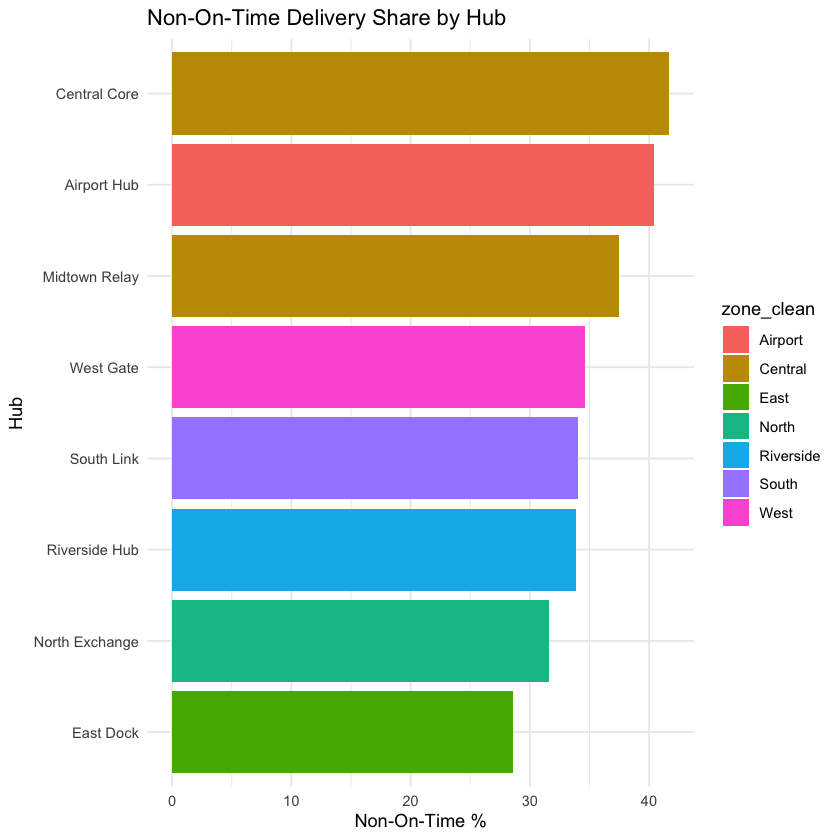

In [5]:
ggplot(hub_risk, aes(x = reorder(hub_name, non_ontime_pct), y = non_ontime_pct, fill = zone_clean)) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Non-On-Time Delivery Share by Hub",
    x = "Hub",
    y = "Non-On-Time %"
  ) +
  theme_minimal()


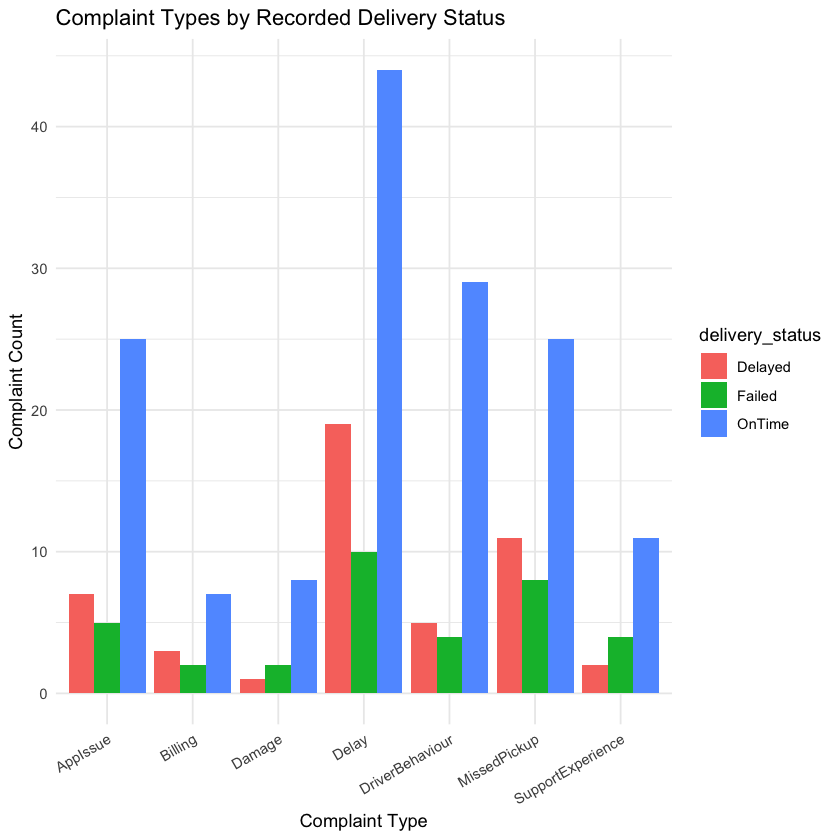

In [6]:
complaint_mix <- dbGetQuery(con, "
SELECT
    c.complaint_type,
    d.delivery_status,
    COUNT(*) AS complaints
FROM complaints c
JOIN deliveries d ON d.order_id = c.order_id
GROUP BY c.complaint_type, d.delivery_status
ORDER BY c.complaint_type, complaints DESC
")

ggplot(complaint_mix, aes(x = complaint_type, y = complaints, fill = delivery_status)) +
  geom_col(position = "dodge") +
  labs(
    title = "Complaint Types by Recorded Delivery Status",
    x = "Complaint Type",
    y = "Complaint Count"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))


## Interpretation

The SQL in R workflow shows that the central operating layer is the weakest service area and that customer dissatisfaction is not fully explained by late or failed statuses alone. The next notebook extends this into Python-based feature engineering and MongoDB Atlas design.
